# Scientific Machine Learning HW 2
Daniel Sun

In [2]:
import torch
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
print(f"Using {device} device")
try:
    print(torch.cuda.get_device_name(device))
except:
    print("CUDA unavailable")
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import pinv

import os
if os.name == 'posix':
    # Cluster
    os.chdir("/home/dsun/PSI-Machine-Learning/Homework 2")
print(os.getcwd())

Using cuda device
NVIDIA GeForce RTX 2080 Ti
/home/dsun/PSI-Machine-Learning/Homework 2


## 2.1 Synthetic Data

In [3]:
# Lotka-Volterra gradient
def grad(_, p, LV_params):
    x, y = p
    alpha, beta, gamma, delta = LV_params
    return np.array([x * (alpha - beta * y), y * (delta * x - gamma)])

# Jacobian
def jac(_, p, LV_params):
    x, y = p
    alpha, beta, gamma, delta = LV_params
    return np.array([[alpha - beta * y, -beta * x], [delta * y, delta * x - gamma]])

In [4]:
params_exact = np.array([0.6, 0.025, 0.5, 0.0125])
t0, tf = (0, 90)
t_exact = np.arange(t0, tf + 1)
p0 = np.array([30, 4]) # Initial condition

In [5]:
p_exact = solve_ivp(grad, (t0, tf), p0, t_eval = t_exact, jac = jac, args = (params_exact,), method = "Radau", dense_output = True).y

In [6]:
noise = np.random.normal(1, 0.1, size = p_exact.shape) # +/- 10% noise
p_noisy = p_exact * noise
t_noisy = t_exact.copy()

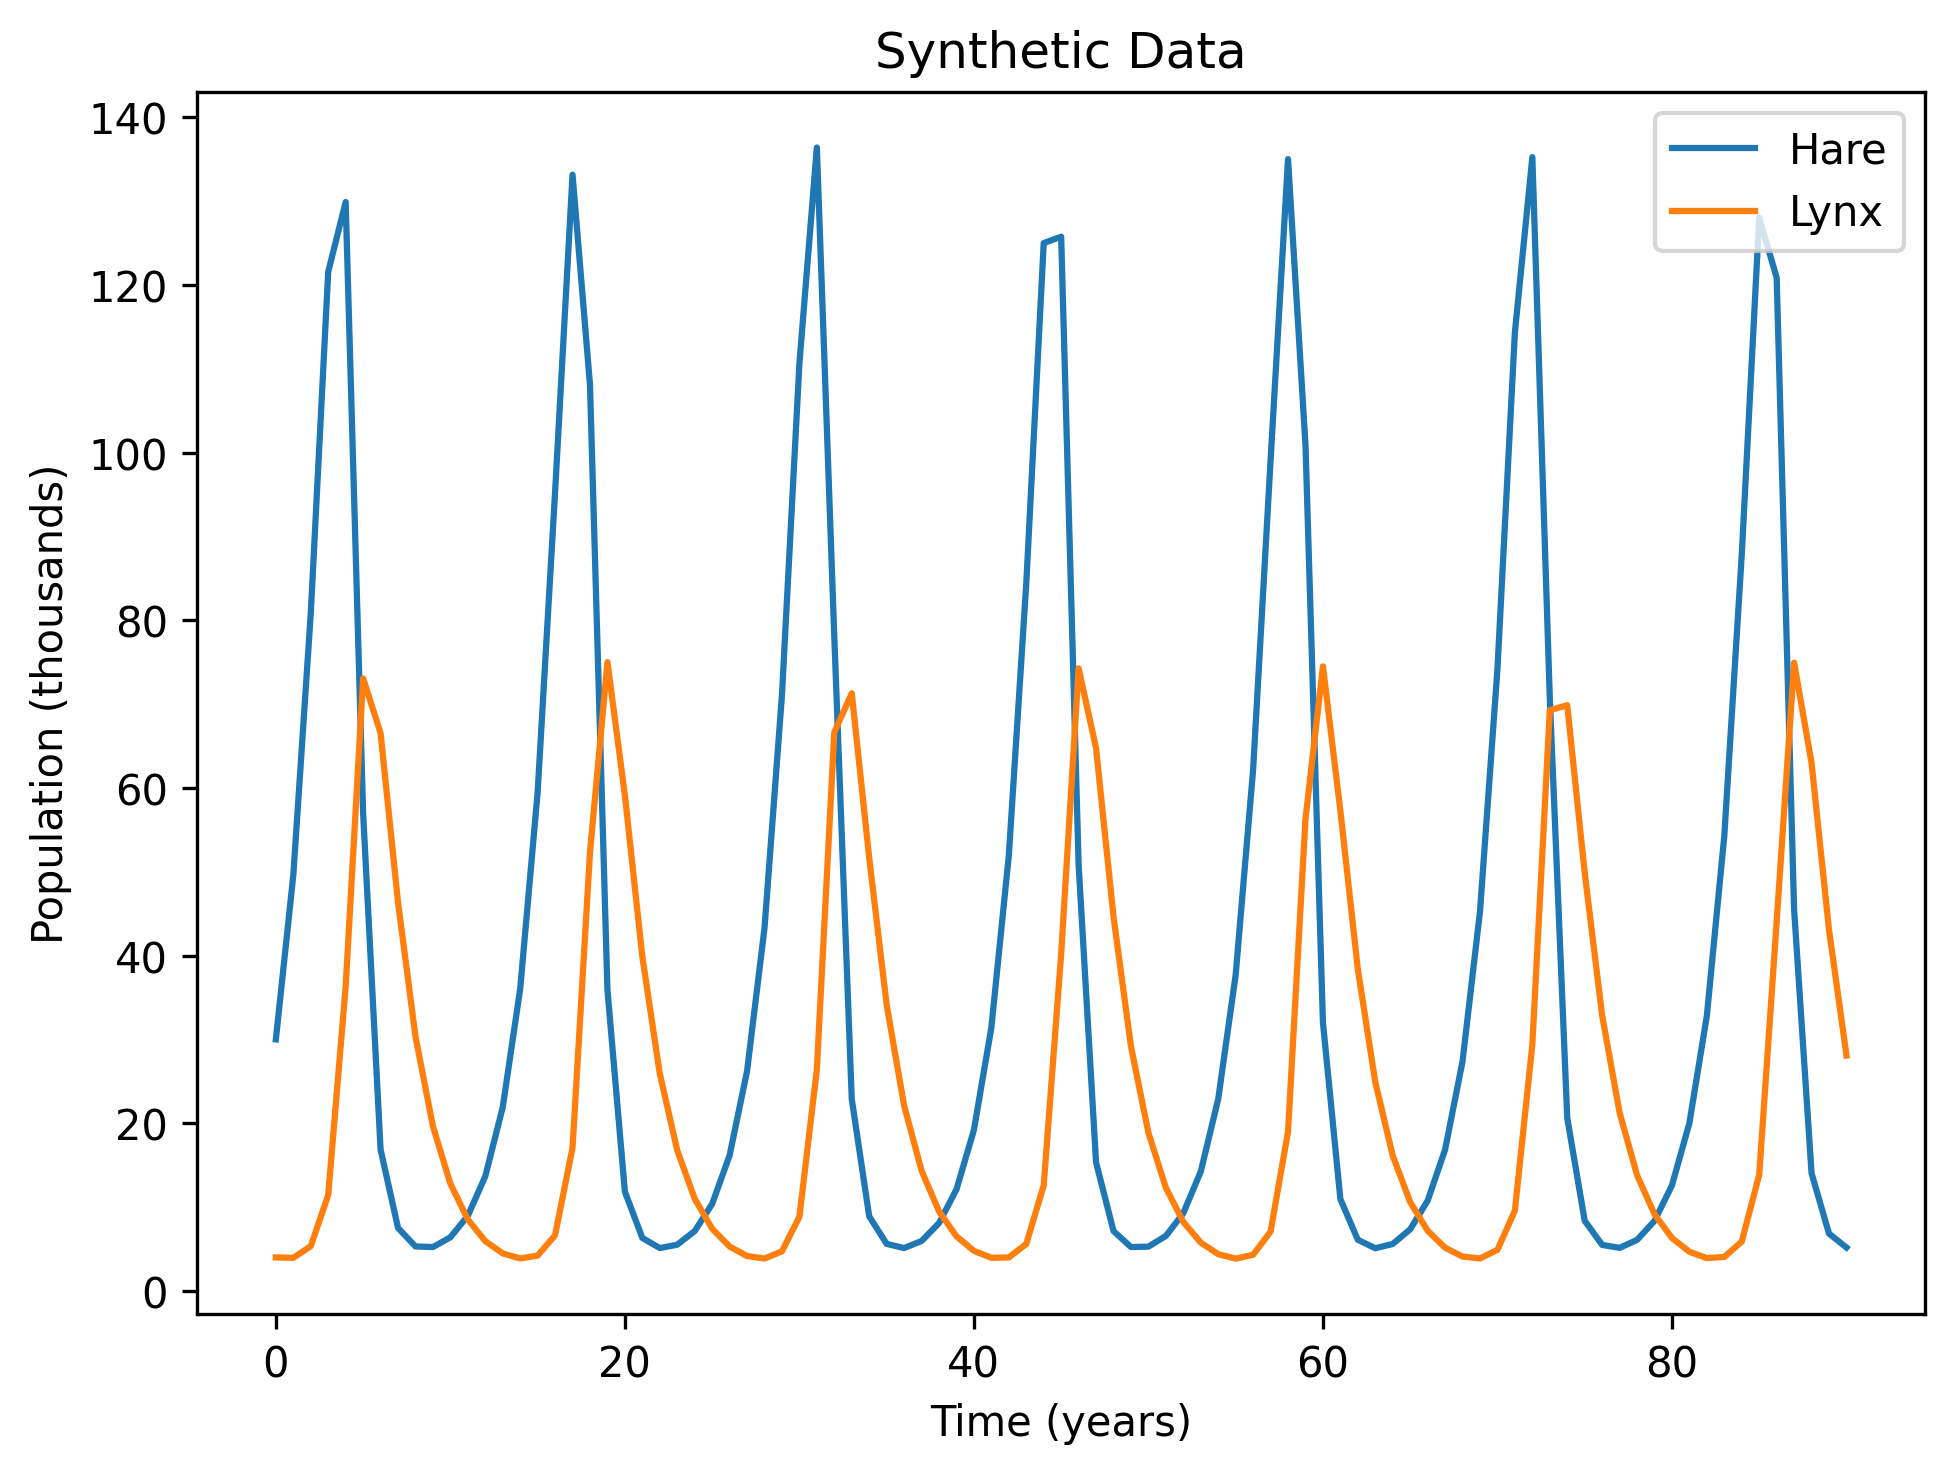

In [7]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_exact, p_exact[0], label = "Hare")
plt.plot(t_exact, p_exact[1], label = "Lynx")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("Synthetic Data")
plt.legend()
plt.savefig("synthetic.pdf")
plt.show()

### 2.1 c) Linear Regression

In [8]:
t_cd = t_exact[1:-1]
dp_cd = (p_exact[:, 2:] - p_exact[:, :-2]) / (t_exact[2:] - t_exact[:-2]) # Approximate derivative via central difference

In [9]:
x_red = p_exact[0, 1:-1]
y_red = p_exact[1, 1:-1]
z_red = np.zeros_like(x_red)
# A @ w = b
A_lr = np.array([[x_red, -x_red * y_red, z_red, z_red], [z_red, z_red, -y_red, x_red * y_red]]).transpose(2, 0, 1).reshape(-1, 4)
b_lr = dp_cd.transpose(1, 0).flatten()

In [10]:
params_lr = pinv(A_lr.T @ A_lr) @ A_lr.T @ b_lr
print("Exact parameters: ", params_exact)
print("Linear regression parameters: ", params_lr)
print("Relative error: ", (params_lr - params_exact) / np.abs(params_exact))

Exact parameters:  [0.6    0.025  0.5    0.0125]
Linear regression parameters:  [0.48525587 0.02023333 0.4058837  0.01019278]
Relative error:  [-0.19124022 -0.19066685 -0.1882326  -0.18457762]


In [11]:
p_lr = solve_ivp(grad, (t0, tf), p0, t_eval = t_exact, jac = jac, args = (params_lr,), method = "Radau", dense_output = True).y

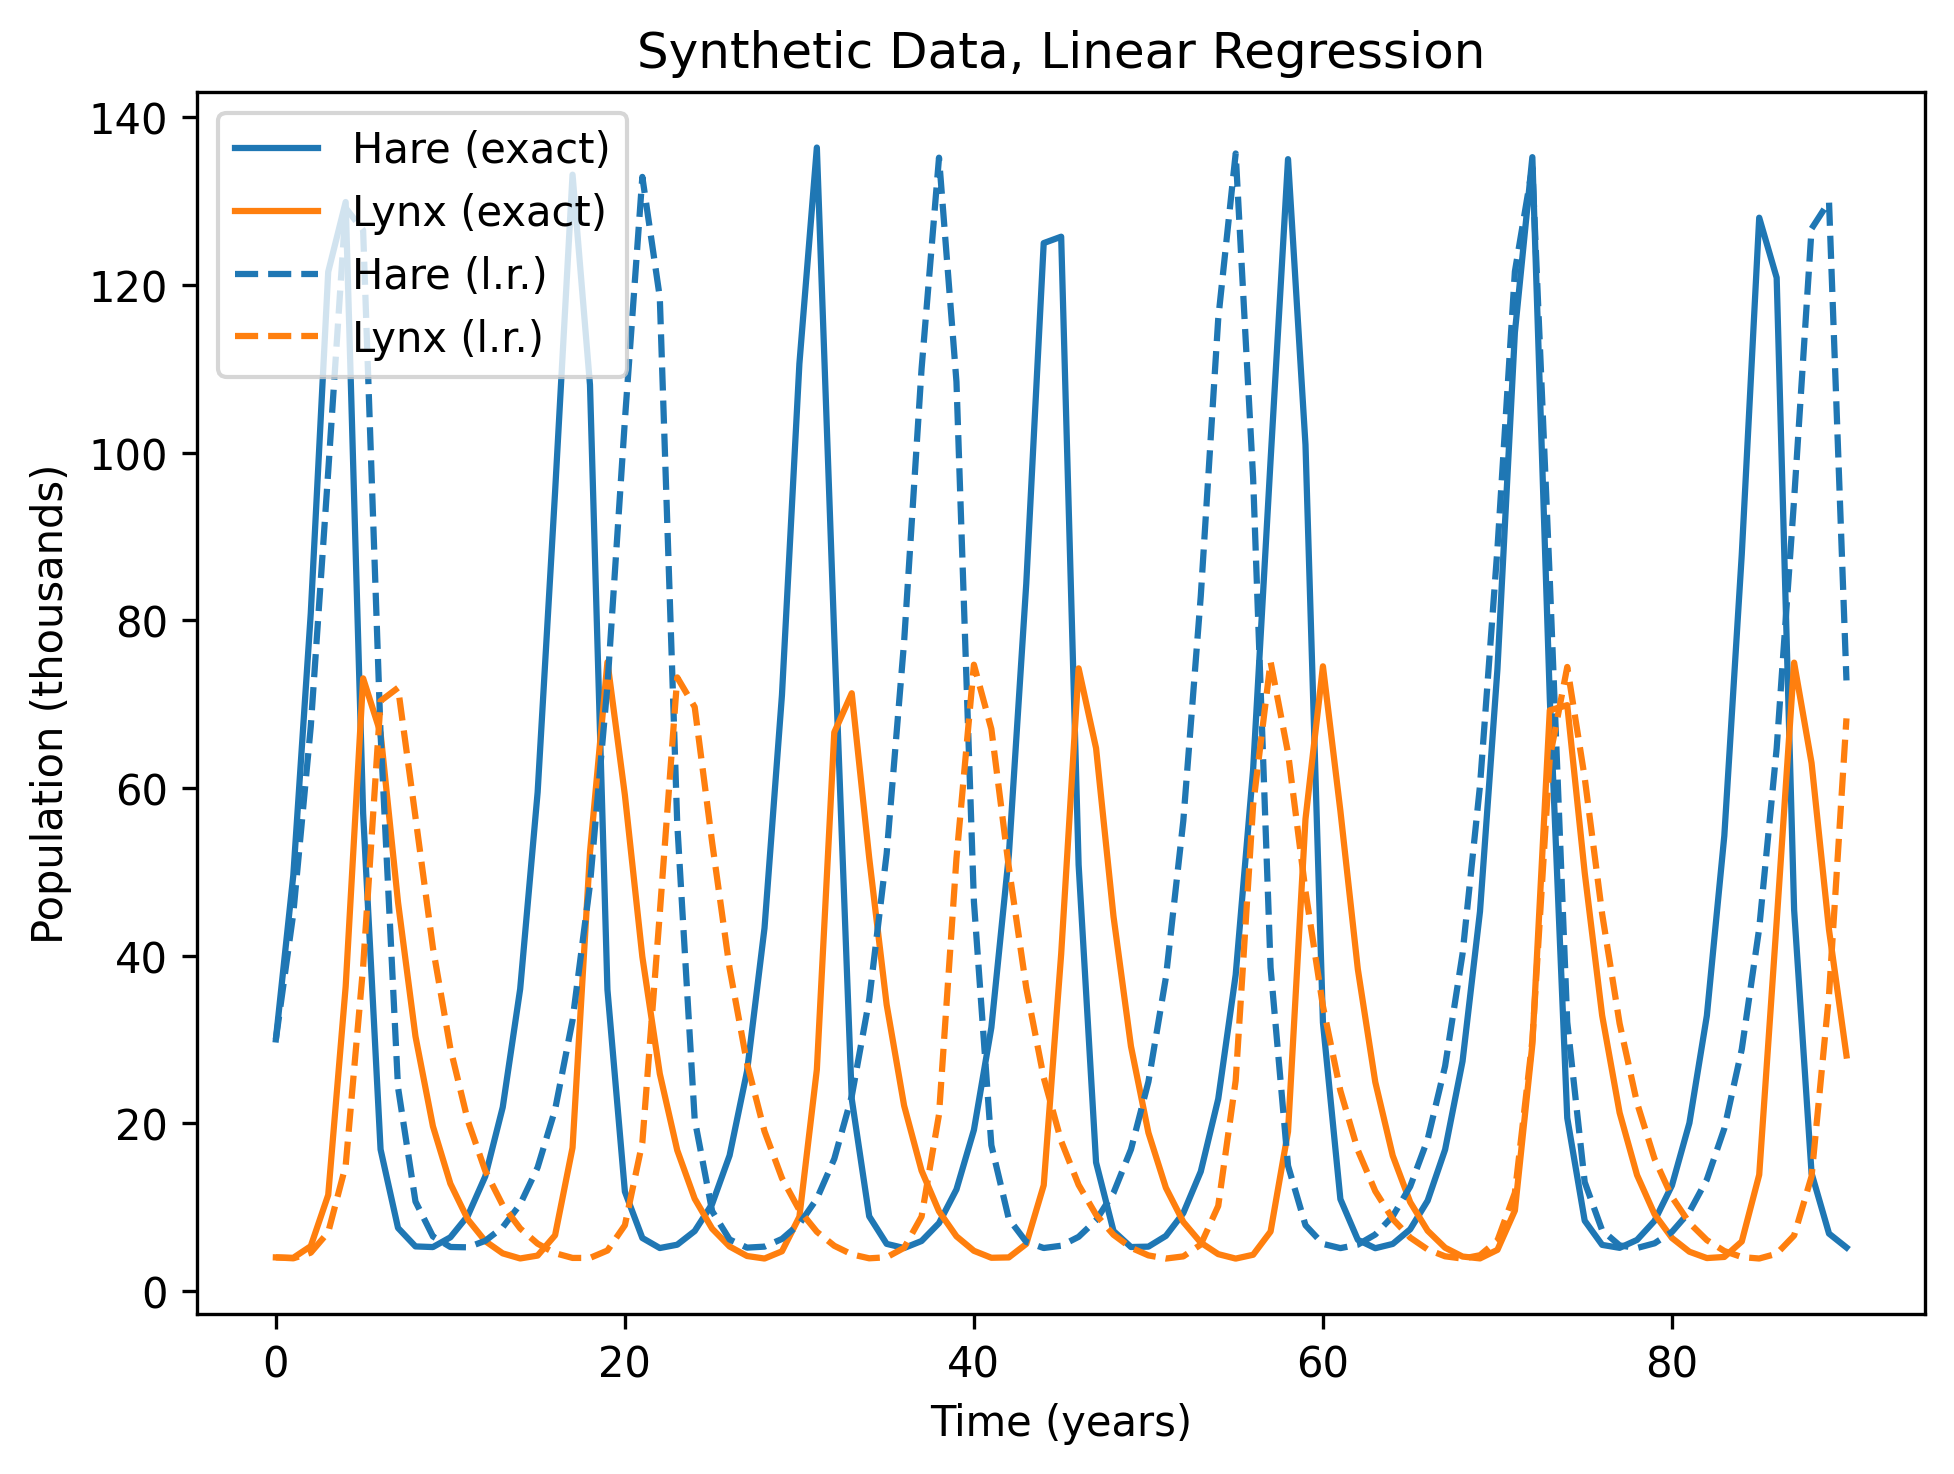

In [12]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_exact, p_exact[0], label = "Hare (exact)")
plt.plot(t_exact, p_exact[1], label = "Lynx (exact)")
plt.plot(t_exact, p_lr[0], label = "Hare (l.r.)", linestyle = "--", color = "C0")
plt.plot(t_exact, p_lr[1], label = "Lynx (l.r.)", linestyle = "--", color = "C1")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("Synthetic Data, Linear Regression")
plt.legend()
plt.savefig("synthetic_lr.pdf")
plt.show()

### 2.1 d) Linear Regression (more samples)

In [13]:
sol_exact_fine = solve_ivp(grad, (t0, tf), p0, jac = jac, args = (params_exact,), method = "Radau", dense_output = True)

In [14]:
t_fine = sol_exact_fine.t
p_fine = sol_exact_fine.y

t_cd_fine = t_fine[1:-1]
dp_cd_fine = (p_fine[:, 2:] - p_fine[:, :-2]) / (t_fine[2:] - t_fine[:-2]) # Approximate derivative via central difference

x_red_fine = p_fine[0, 1:-1]
y_red_fine = p_fine[1, 1:-1]
z_red_fine = np.zeros_like(x_red_fine)
# A @ w = b
A_lr_fine = np.array([[x_red_fine, -x_red_fine * y_red_fine, z_red_fine, z_red_fine], [z_red_fine, z_red_fine, -y_red_fine, x_red_fine * y_red_fine]]).transpose(2, 0, 1).reshape(-1, 4)
b_lr_fine = dp_cd_fine.transpose(1, 0).flatten()
params_lr_fine = pinv(A_lr_fine.T @ A_lr_fine) @ A_lr_fine.T @ b_lr_fine

print("Exact parameters: ", params_exact)
print("Linear regression parameters: ", params_lr_fine)
print("Relative error: ", (params_lr_fine - params_exact) / np.abs(params_exact))

Exact parameters:  [0.6    0.025  0.5    0.0125]
Linear regression parameters:  [0.58091542 0.02422107 0.48270893 0.01209177]
Relative error:  [-0.03180763 -0.0311571  -0.03458215 -0.03265827]


In [15]:
p_lr_fine = solve_ivp(grad, (t0, tf), p0, t_eval = t_fine, jac = jac, args = (params_lr_fine,), method = "Radau", dense_output = True).y

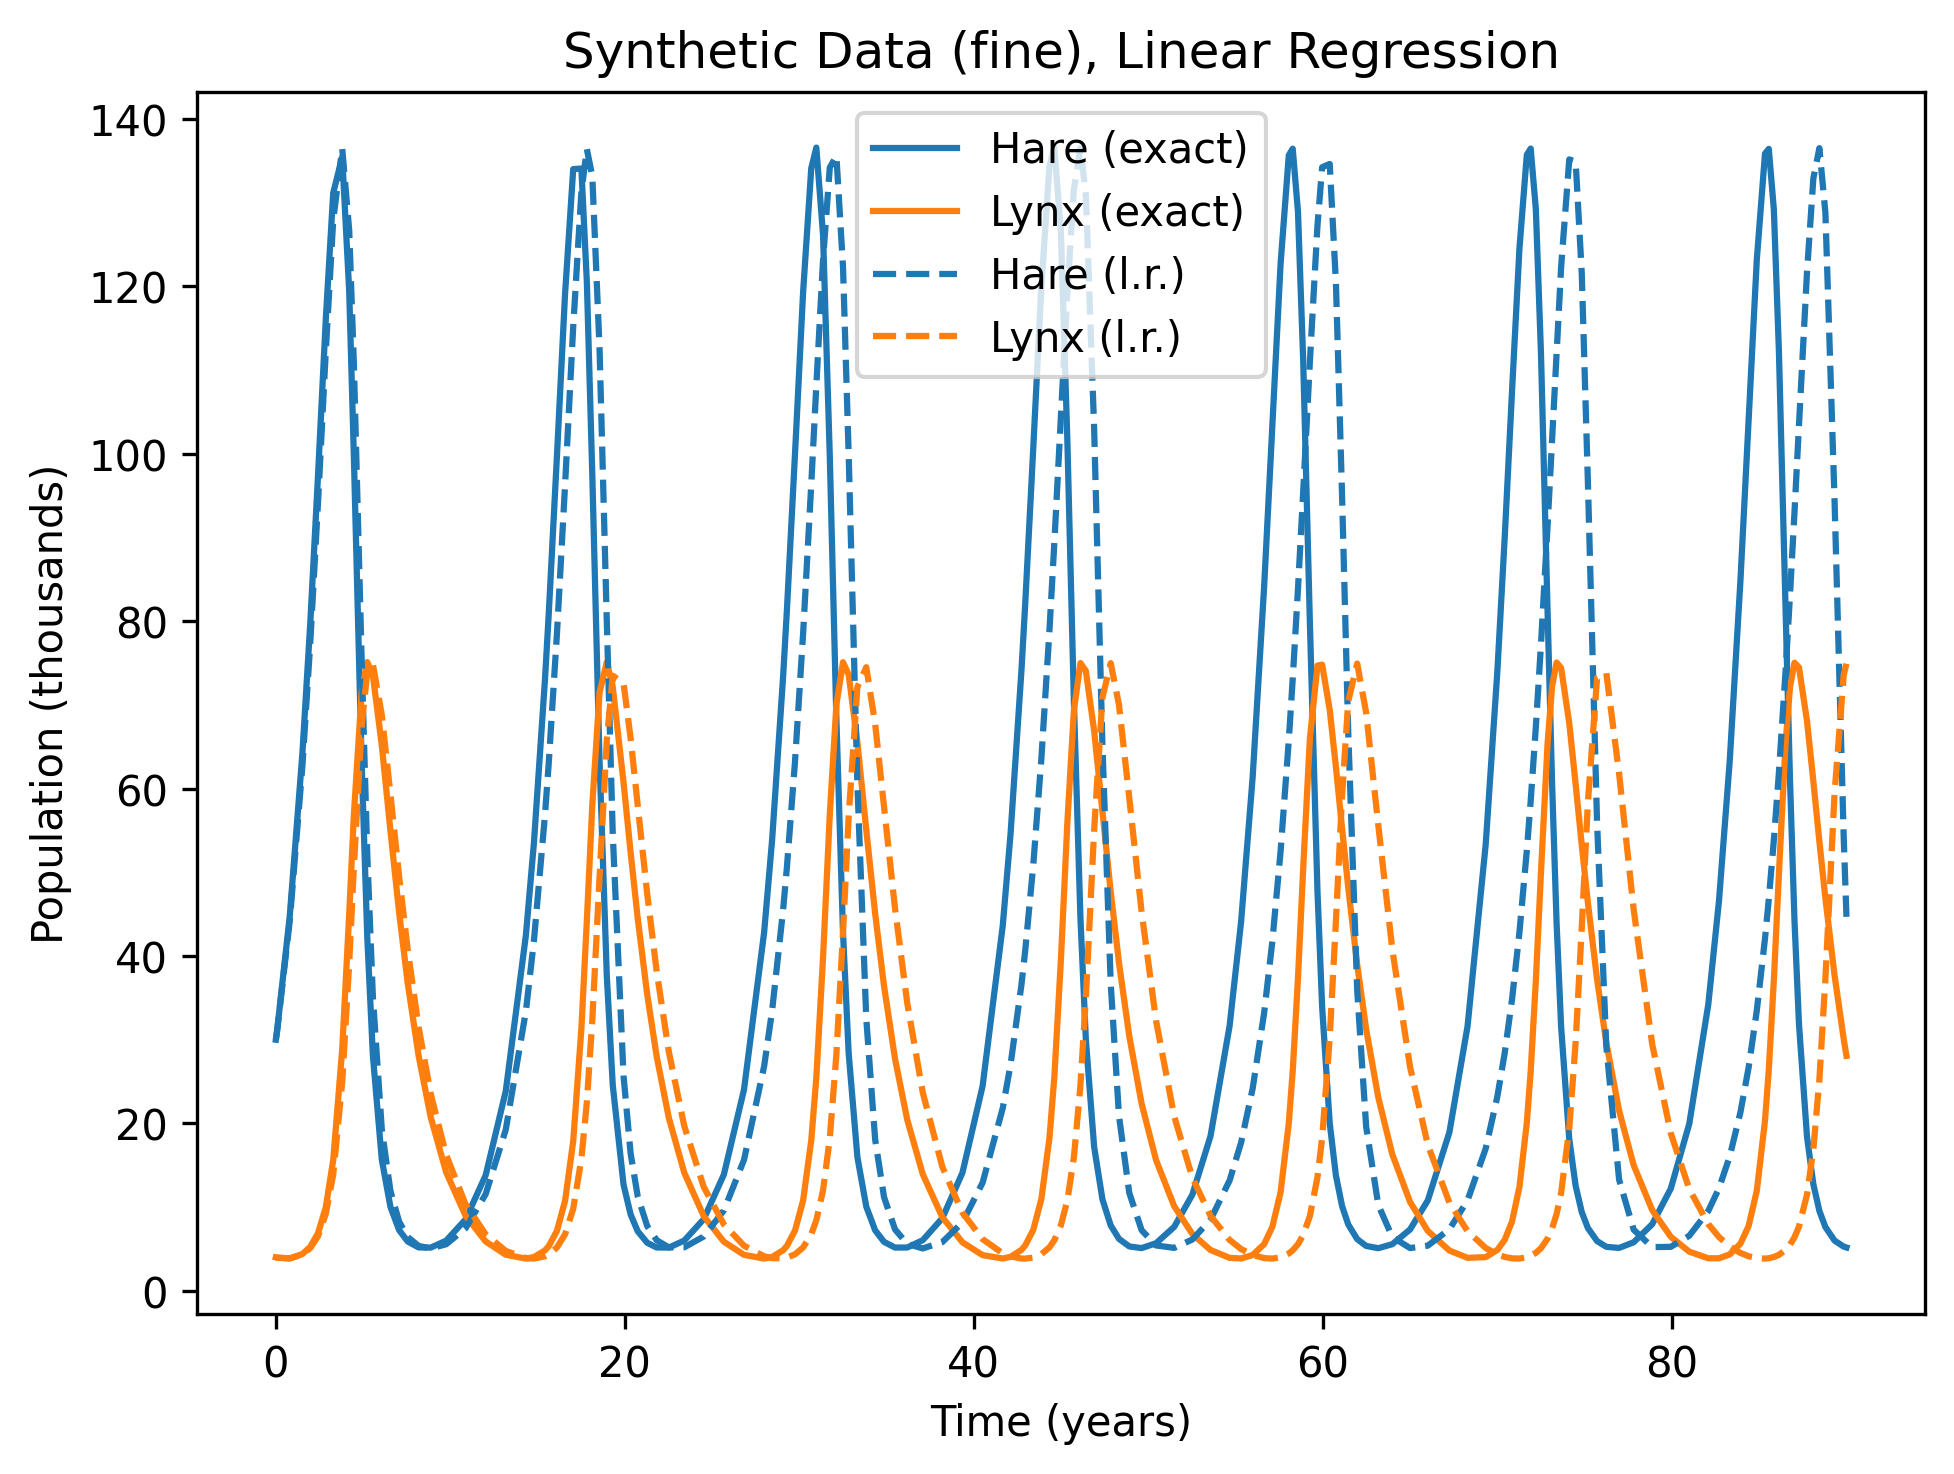

In [16]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_fine, p_fine[0], label = "Hare (exact)")
plt.plot(t_fine, p_fine[1], label = "Lynx (exact)")
plt.plot(t_fine, p_lr_fine[0], label = "Hare (l.r.)", linestyle = "--", color = "C0")
plt.plot(t_fine, p_lr_fine[1], label = "Lynx (l.r.)", linestyle = "--", color = "C1")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("Synthetic Data (fine), Linear Regression")
plt.legend()
plt.savefig("synthetic_lr_fine.pdf")
plt.show()

## 2.2 Hudson's Bay Lynx-Hare Data

In [17]:
lotvol = pd.read_csv("lotvol.csv")
leigh = pd.read_csv("Leigh1968_harelynx.csv")

In [18]:
p_lotvol = lotvol.to_numpy()[:,1:].T
p_leigh = leigh.to_numpy()[:,1:].T

t_lotvol = np.arange(p_lotvol.shape[1])
t_leigh = np.arange(p_leigh.shape[1])

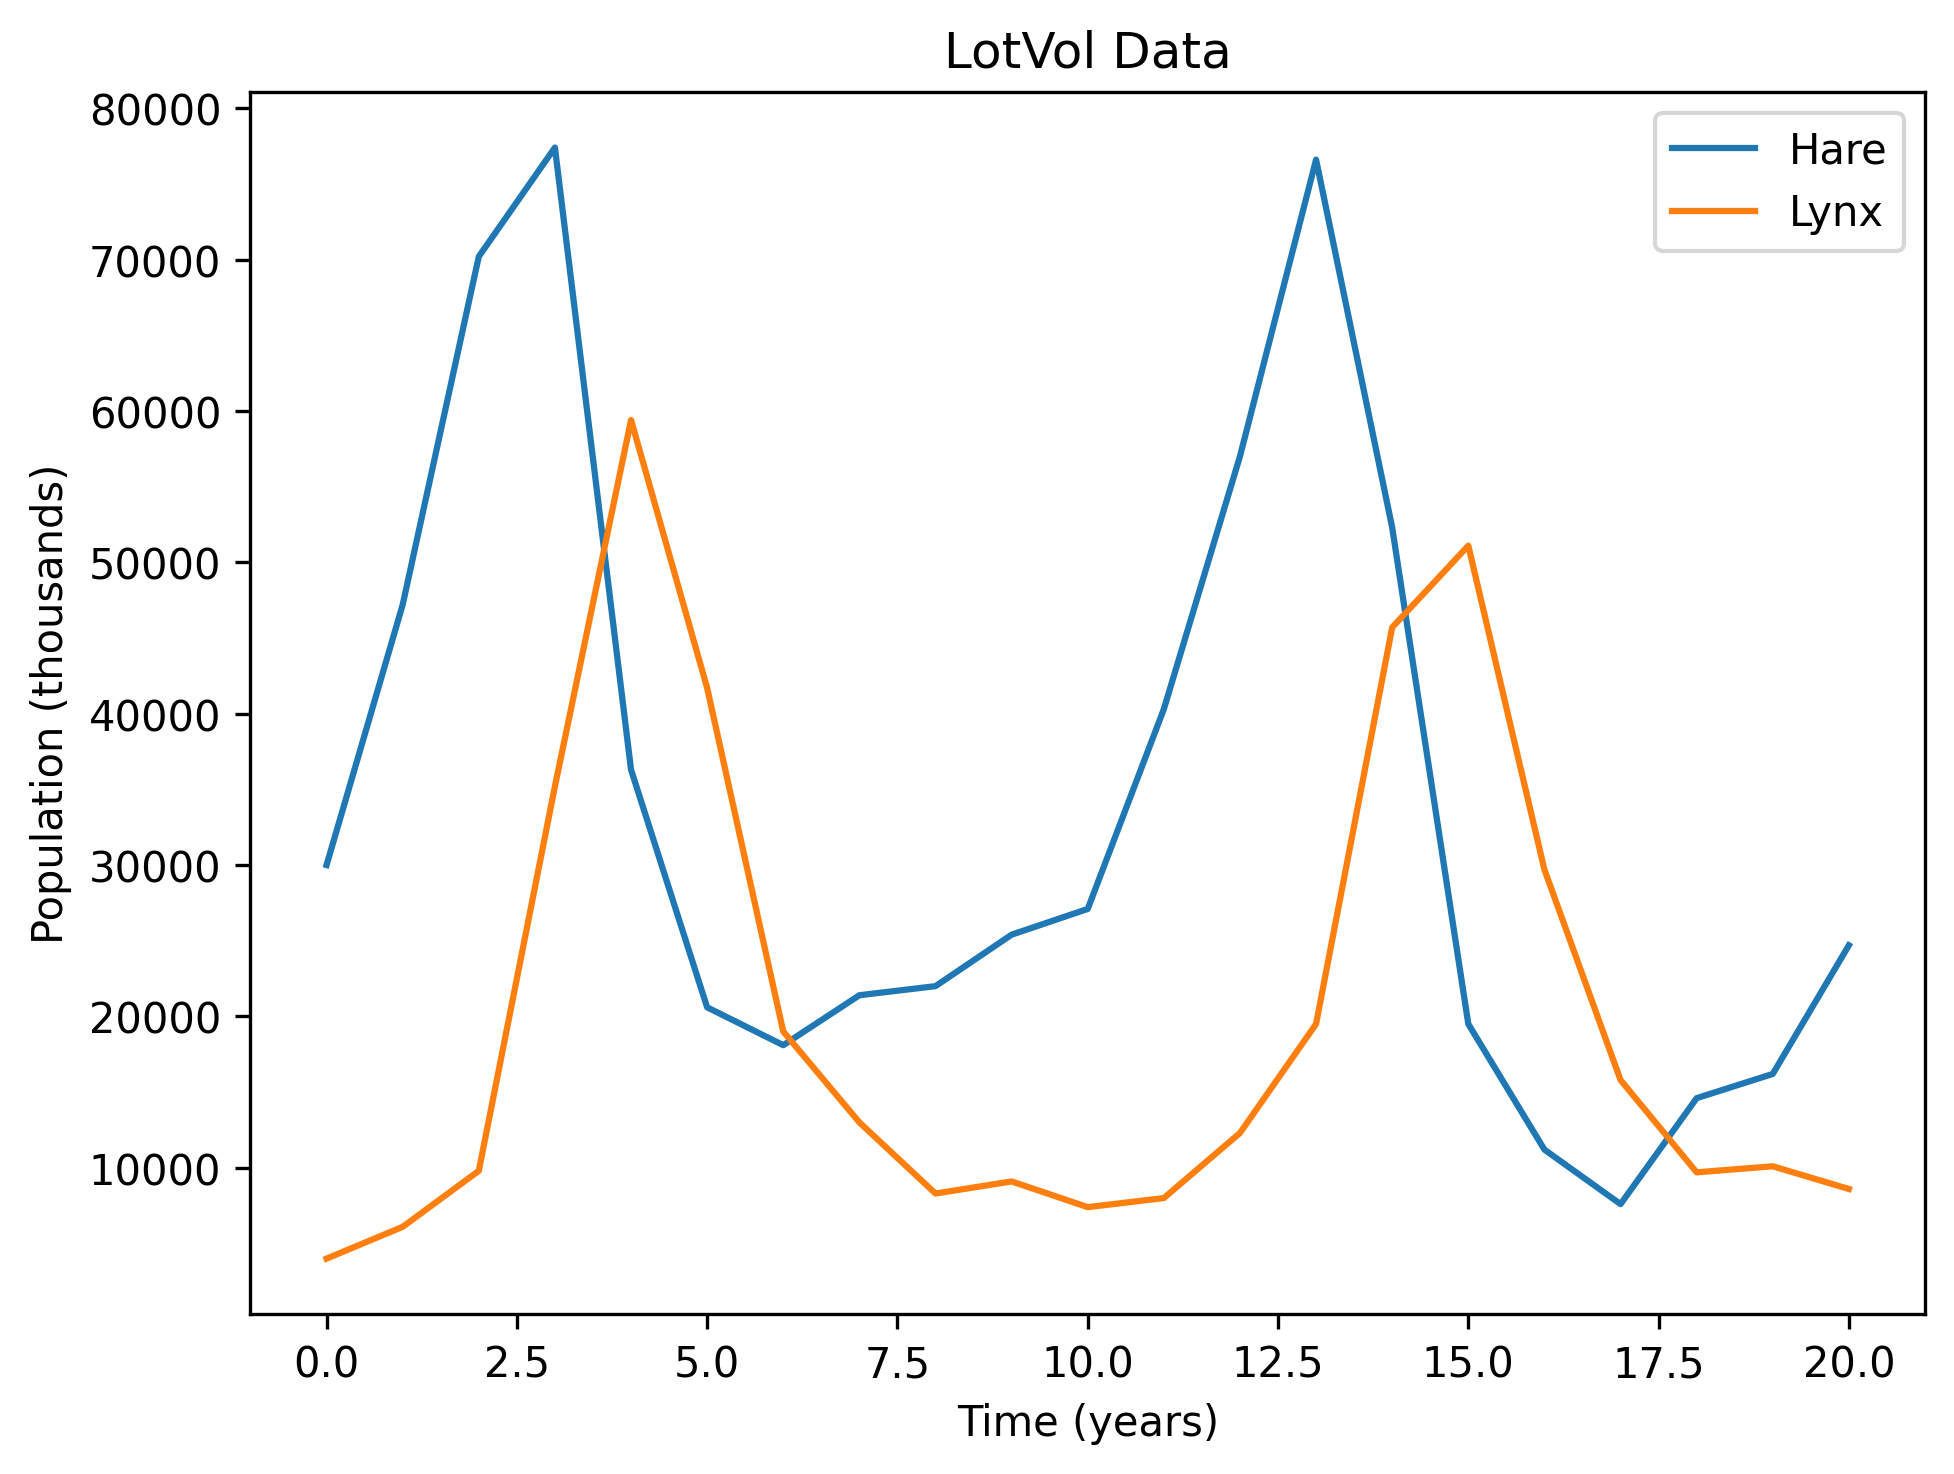

In [19]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_lotvol, p_lotvol[0], label = "Hare")
plt.plot(t_lotvol, p_lotvol[1], label = "Lynx")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("LotVol Data")
plt.legend()
plt.savefig("lotvol.pdf")
plt.show()

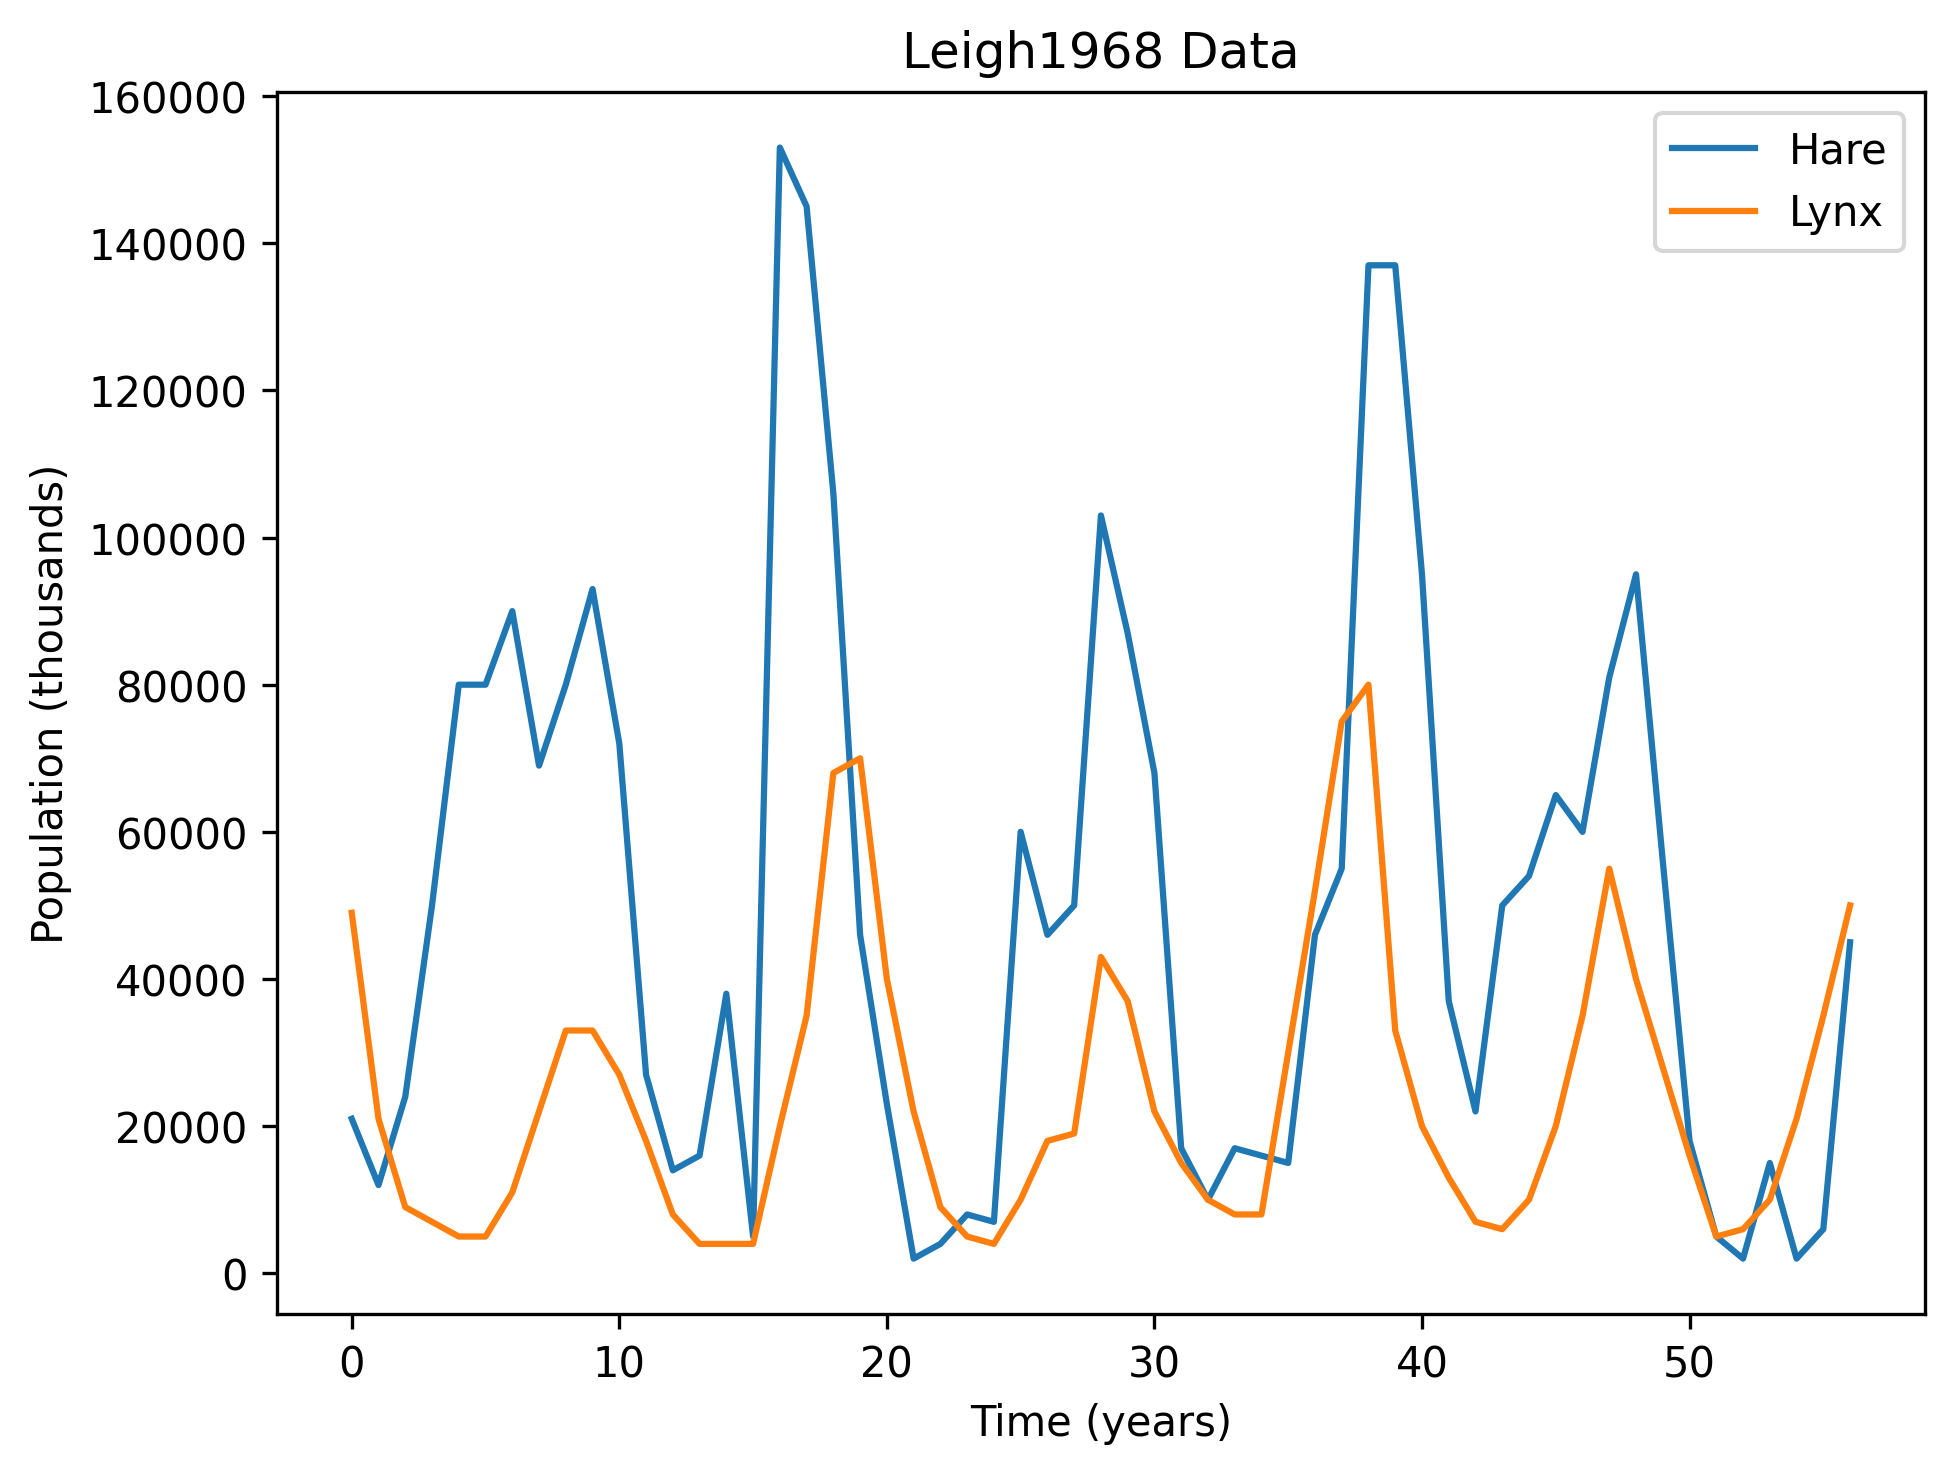

In [20]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_leigh, p_leigh[0], label = "Hare")
plt.plot(t_leigh, p_leigh[1], label = "Lynx")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("Leigh1968 Data")
plt.legend()
plt.savefig("leigh1968.pdf")
plt.show()

### 2.2 c) Linear Regression

In [21]:
t_cd_lotvol = t_lotvol[1:-1]
dp_cd_lotvol = (p_lotvol[:, 2:] - p_lotvol[:, :-2]) / (t_lotvol[2:] - t_lotvol[:-2]) # Approximate derivative via central difference

x_red_lotvol = p_lotvol[0, 1:-1]
y_red_lotvol = p_lotvol[1, 1:-1]
z_red_lotvol = np.zeros_like(x_red_lotvol)
# A @ w = b
A_lr_lotvol = np.array([[x_red_lotvol, -x_red_lotvol * y_red_lotvol, z_red_lotvol, z_red_lotvol], [z_red_lotvol, z_red_lotvol, -y_red_lotvol, x_red_lotvol * y_red_lotvol]]).transpose(2, 0, 1).reshape(-1, 4)
b_lr_lotvol = dp_cd_lotvol.transpose(1, 0).flatten()
params_lr_lotvol = pinv(A_lr_lotvol.T @ A_lr_lotvol) @ A_lr_lotvol.T @ b_lr_lotvol

print("Linear regression parameters: ", params_lr_lotvol)

Linear regression parameters:  [-3.37325556e-01 -1.43636099e-05 -3.13189221e-01 -8.72661105e-06]


In [22]:
p_lr_lotvol = solve_ivp(grad, (0, t_lotvol.shape[0] - 1), p_lotvol[:, 0], t_eval = t_lotvol, jac = jac, args = (params_lr_lotvol,), method = "Radau", dense_output = True).y

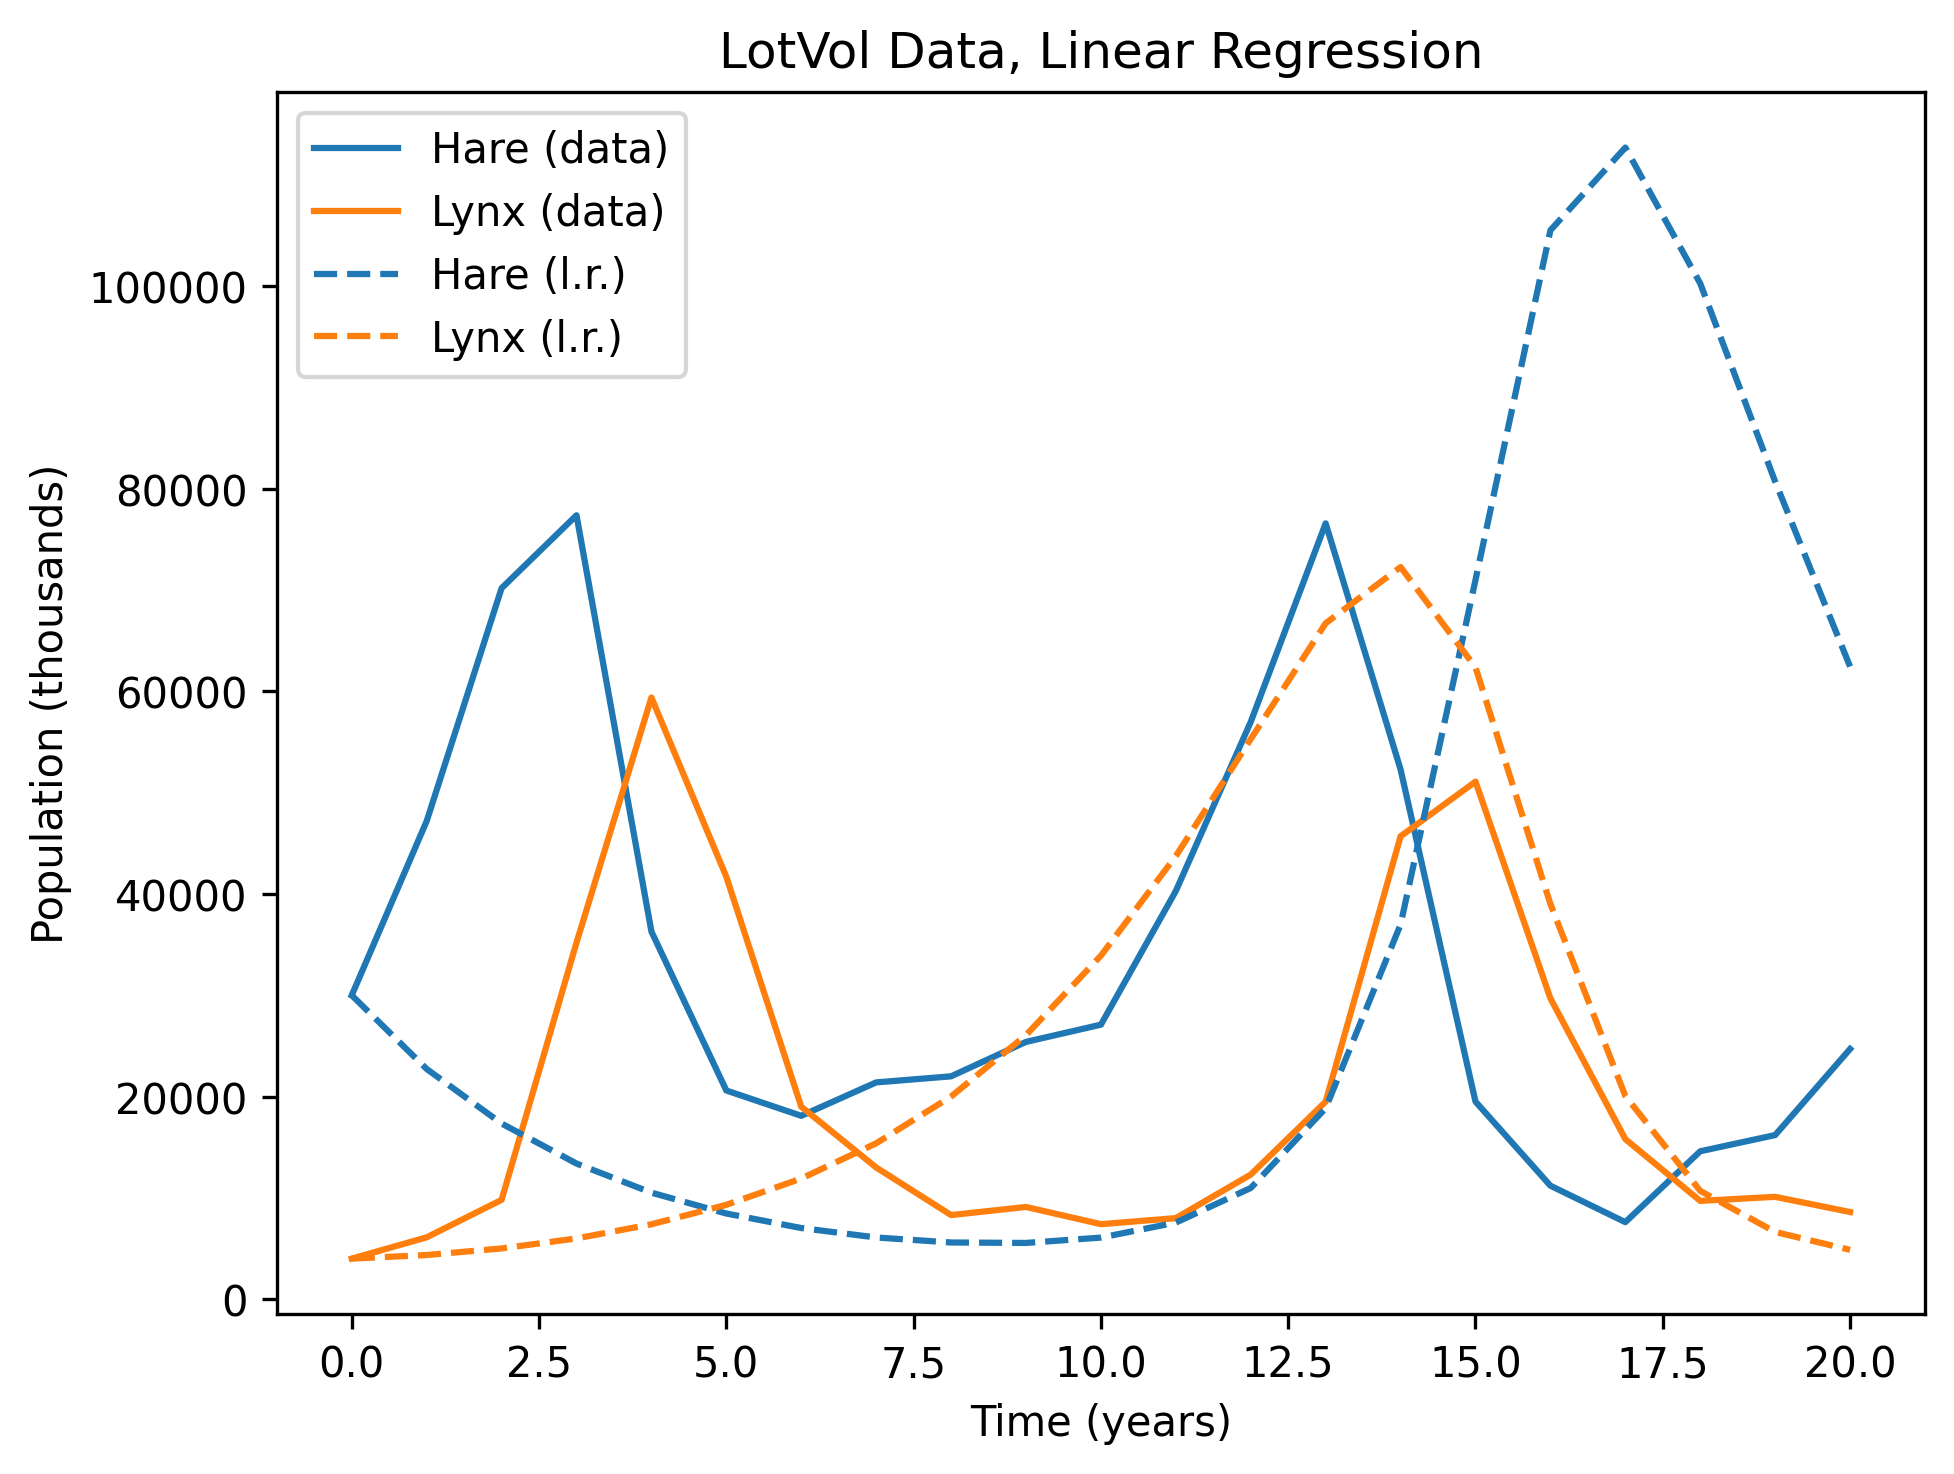

In [23]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_lotvol, p_lotvol[0], label = "Hare (data)")
plt.plot(t_lotvol, p_lotvol[1], label = "Lynx (data)")
plt.plot(t_lotvol, p_lr_lotvol[0], label = "Hare (l.r.)", linestyle = "--", color = "C0")
plt.plot(t_lotvol, p_lr_lotvol[1], label = "Lynx (l.r.)", linestyle = "--", color = "C1")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("LotVol Data, Linear Regression")
plt.legend()
plt.savefig("lotvol_lr.pdf")
plt.show()

In [24]:
t_cd_leigh = t_leigh[1:-1]
dp_cd_leigh = (p_leigh[:, 2:] - p_leigh[:, :-2]) / (t_leigh[2:] - t_leigh[:-2]) # Approximate derivative via central difference

x_red_leigh = p_leigh[0, 1:-1]
y_red_leigh = p_leigh[1, 1:-1]
z_red_leigh = np.zeros_like(x_red_leigh)
# A @ w = b
A_lr_leigh = np.array([[x_red_leigh, -x_red_leigh * y_red_leigh, z_red_leigh, z_red_leigh], [z_red_leigh, z_red_leigh, -y_red_leigh, x_red_leigh * y_red_leigh]]).transpose(2, 0, 1).reshape(-1, 4)
b_lr_leigh = dp_cd_leigh.transpose(1, 0).flatten()
params_lr_leigh = pinv(A_lr_leigh.T @ A_lr_leigh) @ A_lr_leigh.T @ b_lr_leigh

print("Linear regression parameters: ", params_lr_leigh)

Linear regression parameters:  [2.30119574e-03 6.63643820e-08 7.20591921e-03 1.90080482e-07]


In [25]:
p_lr_leigh = solve_ivp(grad, (0, t_leigh.shape[0] - 1), p_leigh[:, 0], t_eval = t_leigh, jac = jac, args = (params_lr_leigh,), method = "Radau", dense_output = True).y

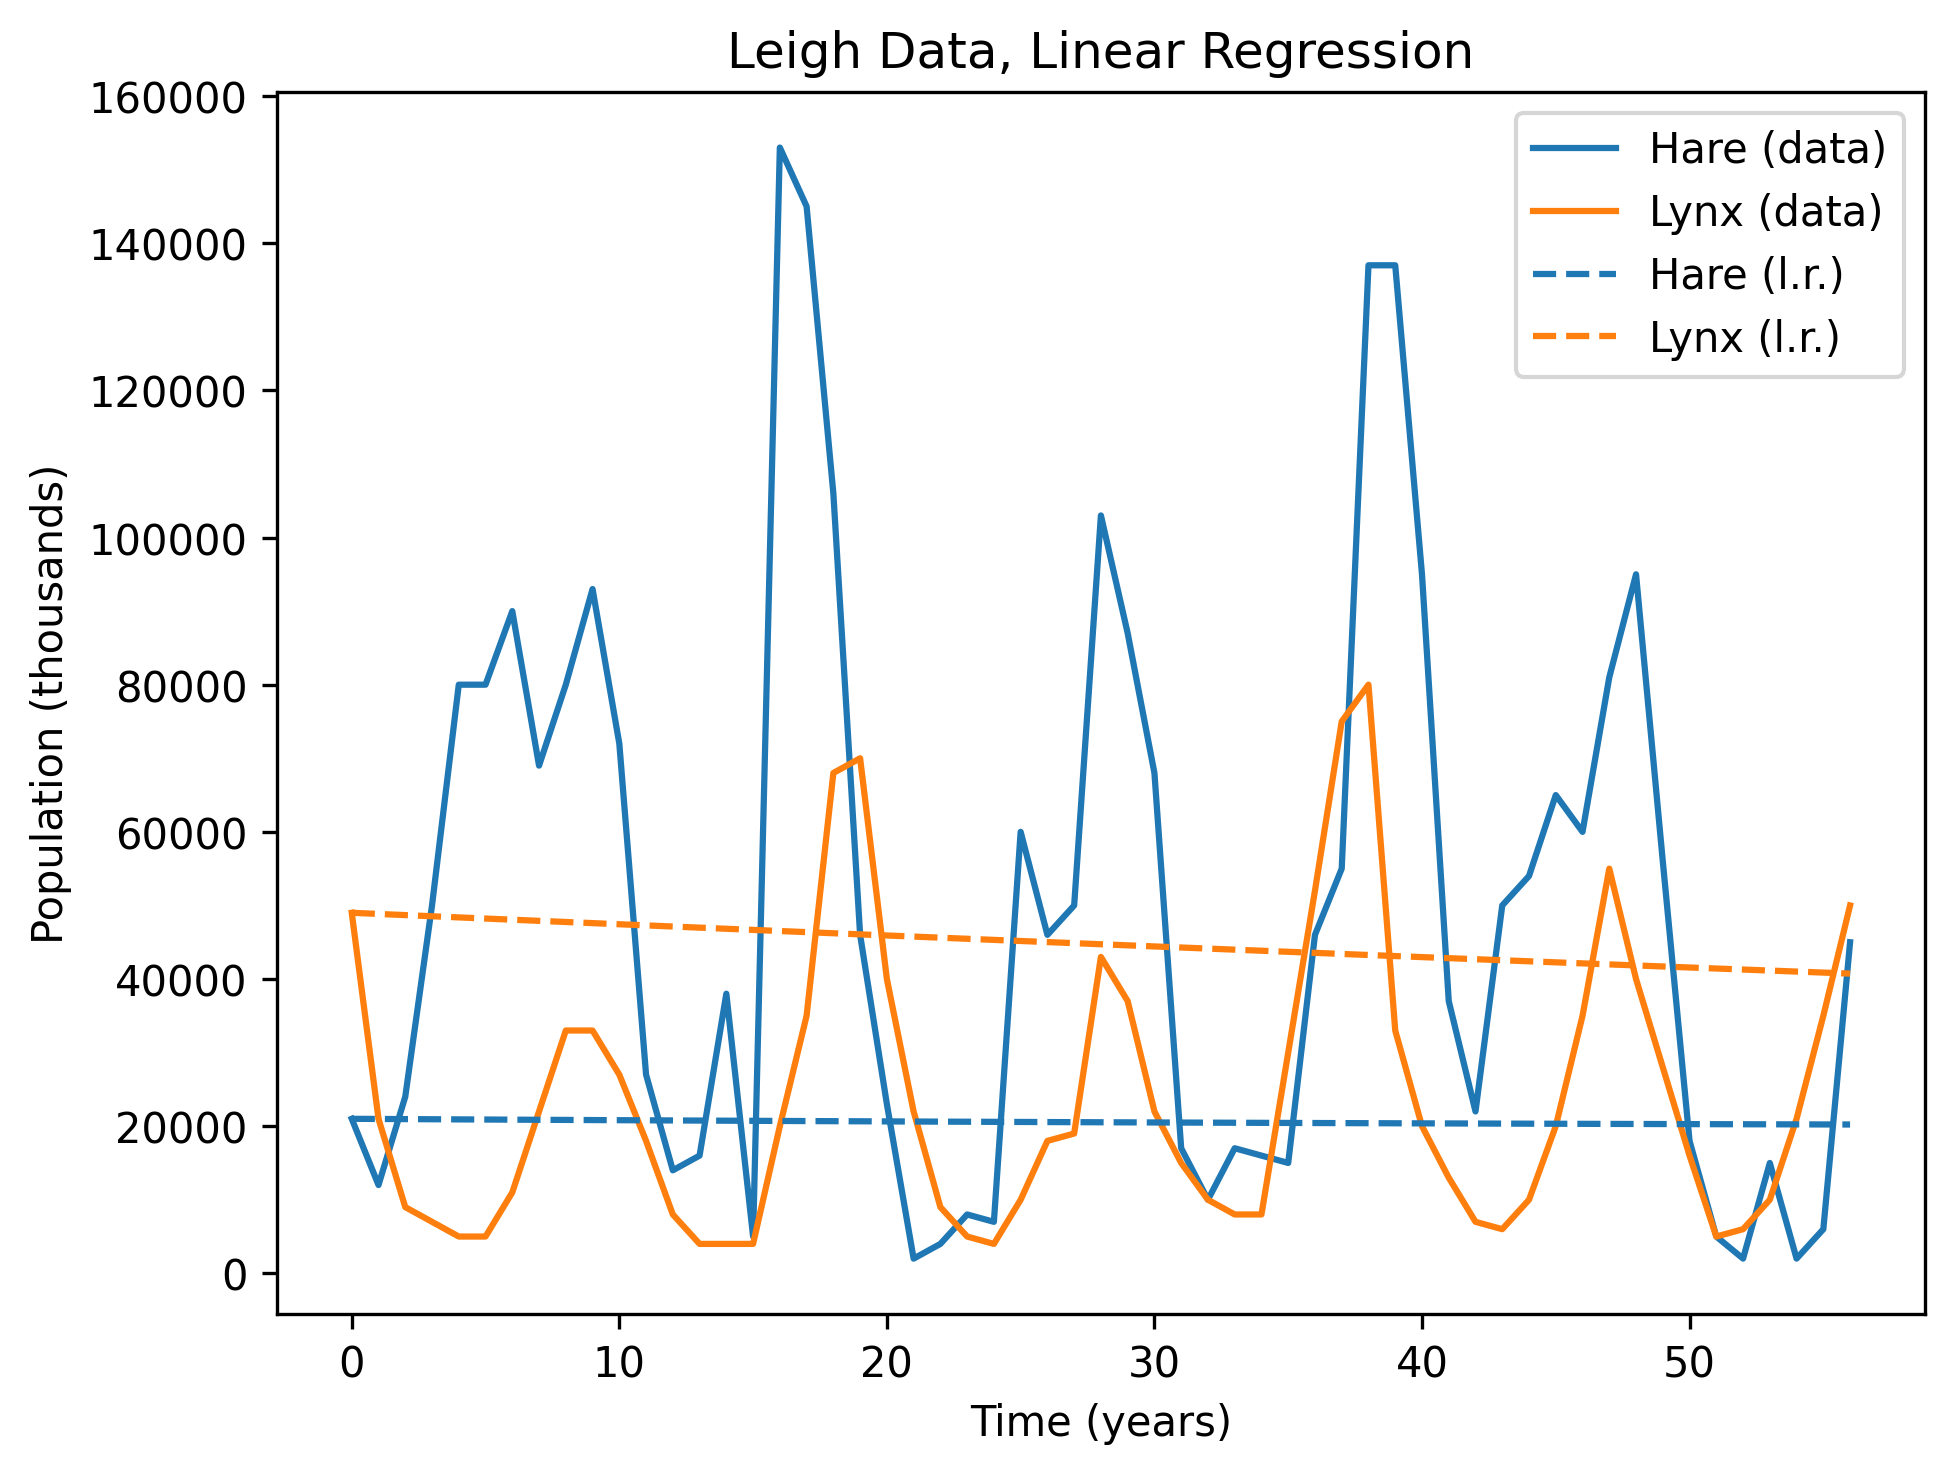

In [26]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_leigh, p_leigh[0], label = "Hare (data)")
plt.plot(t_leigh, p_leigh[1], label = "Lynx (data)")
plt.plot(t_leigh, p_lr_leigh[0], label = "Hare (l.r.)", linestyle = "--", color = "C0")
plt.plot(t_leigh, p_lr_leigh[1], label = "Lynx (l.r.)", linestyle = "--", color = "C1")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("Leigh Data, Linear Regression")
plt.legend()
plt.savefig("leigh_lr.pdf")
plt.show()

## 2.3 NN and PINN

In [61]:
dataset_exact = TensorDataset(torch.from_numpy(t_exact).float(), torch.from_numpy(p_exact.T).float())
dataset_exact_train, dataset_exact_test = random_split(dataset_exact, [3/4, 1/4])
dataset_exact_train_loader = DataLoader(dataset_exact_train, shuffle = True, pin_memory = True, batch_size = dataset_exact_train.__len__())
dataset_exact_test_loader = DataLoader(dataset_exact_test, shuffle = False, pin_memory = True, batch_size = dataset_exact_test.__len__())

dataset_noisy = TensorDataset(torch.from_numpy(t_noisy).float(), torch.from_numpy(p_noisy.T).float())
dataset_noisy_train, dataset_noisy_test = random_split(dataset_noisy, [3/4, 1/4])
dataset_noisy_train_loader = DataLoader(dataset_noisy_train, shuffle = True, pin_memory = True)
dataset_noisy_test_loader = DataLoader(dataset_noisy_test, shuffle = False, pin_memory = True)

dataset_lotvol = TensorDataset(torch.from_numpy(t_lotvol).float(), torch.from_numpy(p_lotvol.T).float())
dataset_lotvol_train, dataset_lotvol_test = random_split(dataset_lotvol, [3/4, 1/4])
dataset_lotvol_train_loader = DataLoader(dataset_lotvol_train, shuffle = True, pin_memory = True)
dataset_lotvol_test_loader = DataLoader(dataset_lotvol_test, shuffle = False, pin_memory = True)

dataset_leigh = TensorDataset(torch.from_numpy(t_leigh).float(), torch.from_numpy(p_leigh.T).float())
dataset_leigh_train, dataset_leigh_test = random_split(dataset_leigh, [3/4, 1/4])
dataset_leigh_train_loader = DataLoader(dataset_leigh_train, shuffle = True, pin_memory = True)
dataset_leigh_test_loader = DataLoader(dataset_leigh_test, shuffle = False, pin_memory = True)

### 2.3 a) NN

In [62]:
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.linear_relu_stack(x)

In [63]:
model = NN().to(device)
print(model)

NN(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [64]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [83]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.unsqueeze(-1).to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # if batch % 100 == 0:
        #     loss, current = loss.item(), (batch + 1) * len(X)
        #     print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [84]:
def test(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.unsqueeze(-1).to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    print(f"Test Error: \n Avg loss: {test_loss:>8f} \n")

In [85]:
epochs = 10000
for t in tqdm(range(epochs)):
    train(dataset_exact_train_loader, model, loss_fn, optimizer)
    if t % 2500 == 0:
        print(f"Epoch {t}")
        test(dataset_exact_test_loader, model, loss_fn)

  0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 0
Test Error: 
 Avg loss: 1282.567627 

Epoch 2500
Test Error: 
 Avg loss: 1673.003052 

Epoch 5000
Test Error: 
 Avg loss: 1619.914062 

Epoch 7500
Test Error: 
 Avg loss: 1610.003784 



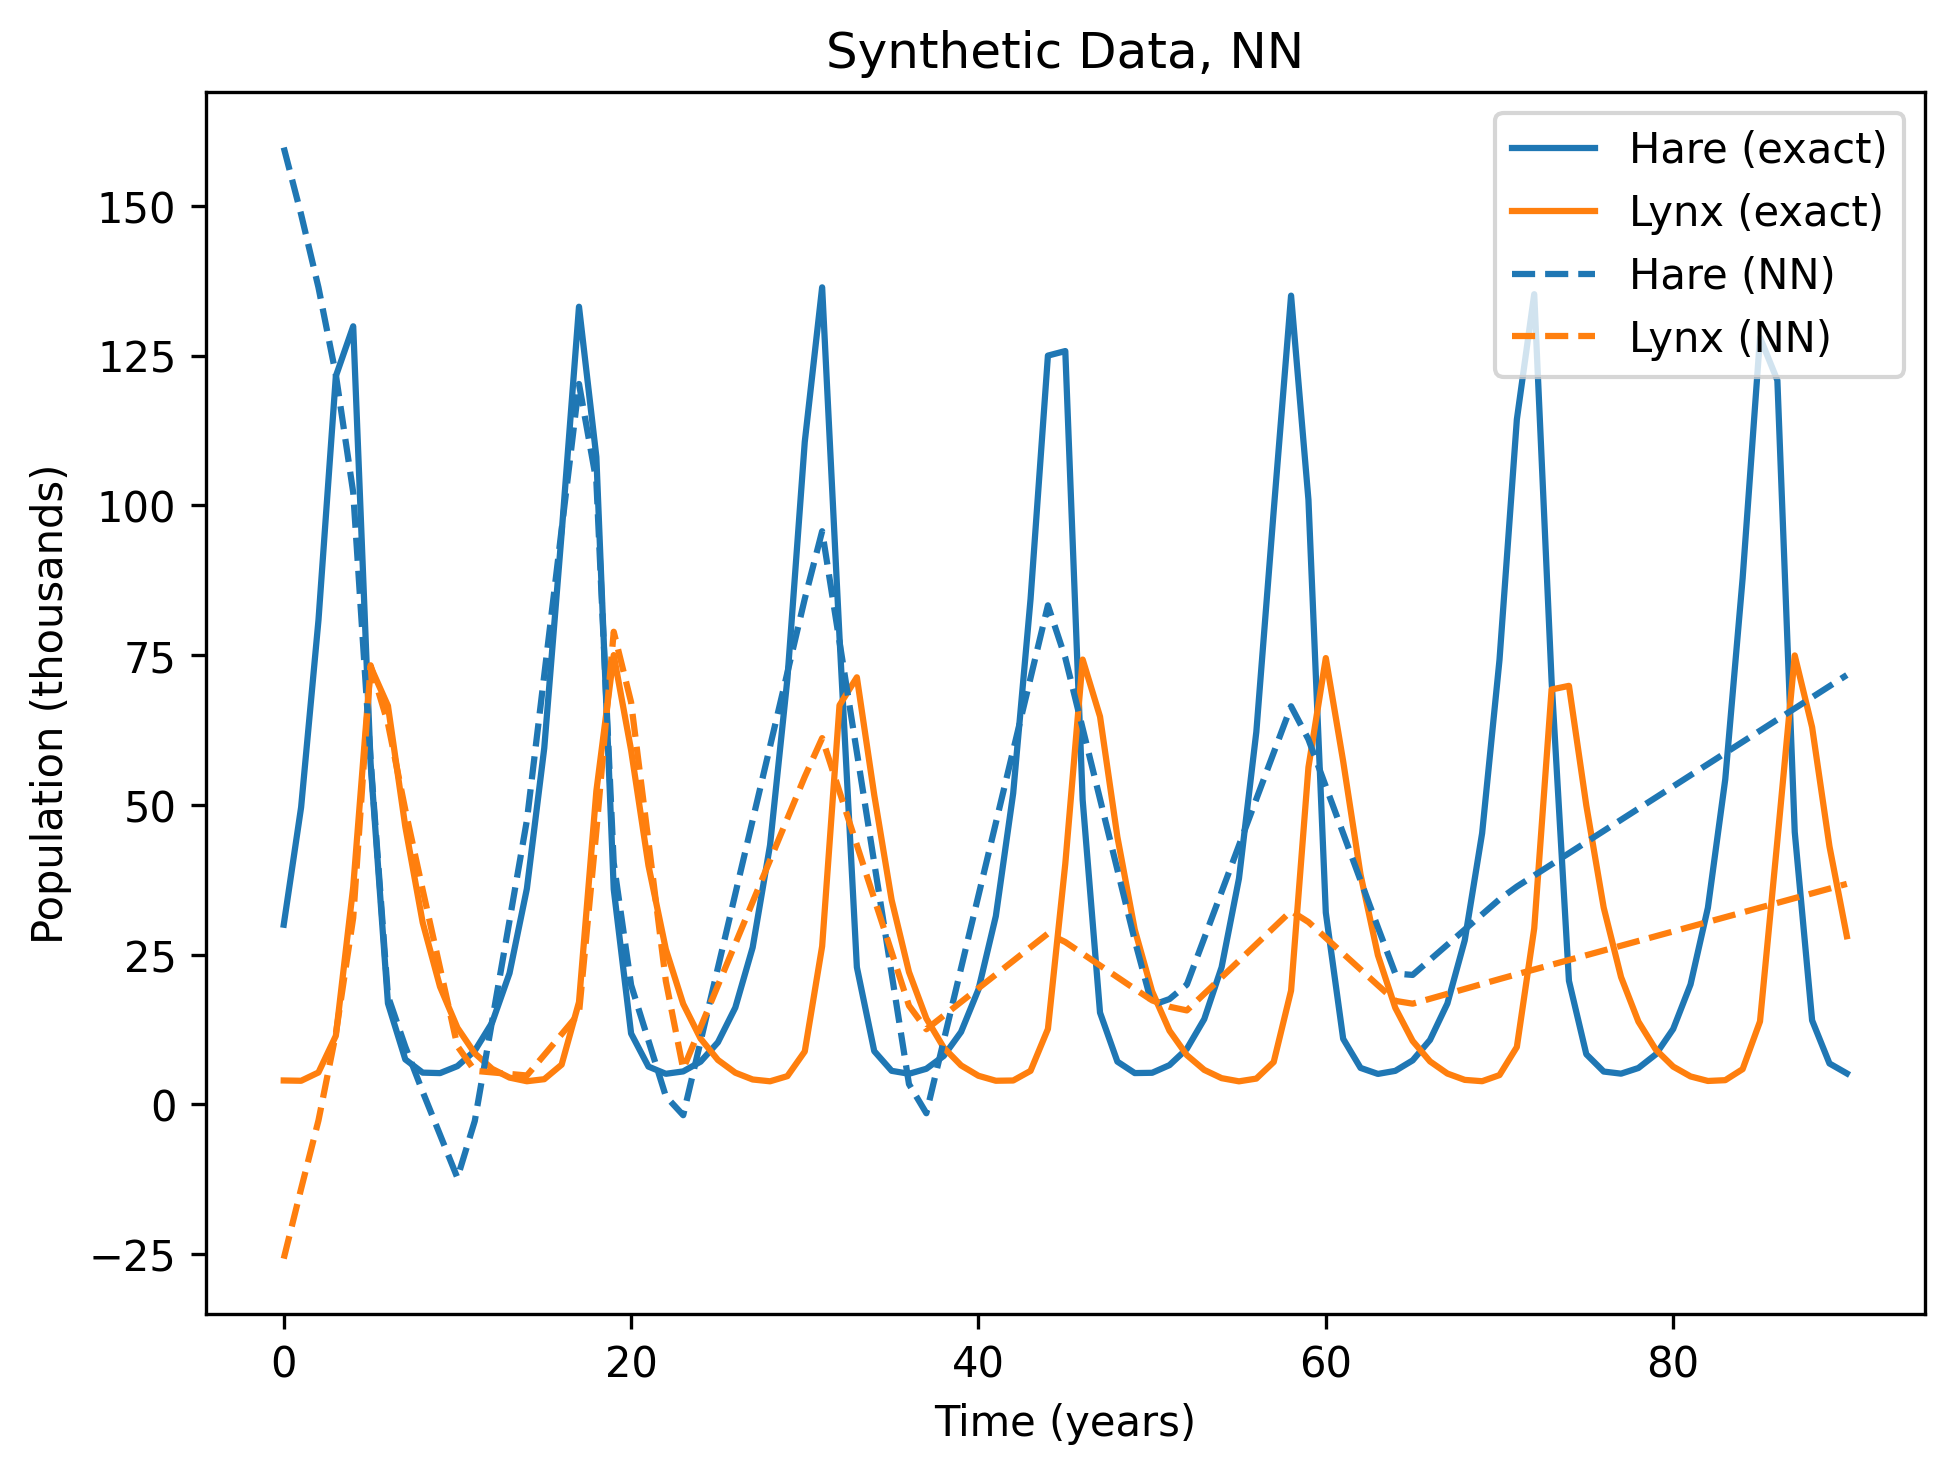

In [93]:
v_pred = model(torch.from_numpy(t_exact).float().unsqueeze(-1).to(device)).detach().cpu().numpy().T
plt.figure(dpi = 300, layout = "constrained")
plt.plot(t_exact, p_exact[0], label = "Hare (exact)")
plt.plot(t_exact, p_exact[1], label = "Lynx (exact)")
plt.plot(t_exact, v_pred[0], label = "Hare (NN)", linestyle = "--", color = "C0")
plt.plot(t_exact, v_pred[1], label = "Lynx (NN)", linestyle = "--", color = "C1")
plt.xlabel("Time (years)")
plt.ylabel("Population (thousands)")
plt.title("Synthetic Data, NN")
plt.legend()
plt.show()